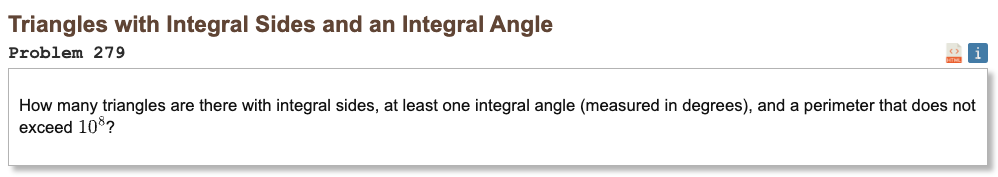

## Initial approach

* use the law of cosines first, because with integer sides the cosine of any triangle angle is rational
* then Niven’s theorem collapses the search to only three possible integer angles, 60, 90, and 120 degrees
* so the problem becomes counting all integer triangles of those three types with perimeter at most 10^8
* for 90 degrees, use the standard primitive Pythagorean parametrization and add all valid multiples
* for 60 and 120 degrees, use the Eisenstein-style parametrizations, again counting all multiples of each primitive base triangle
* in the 60 and 120 cases, the generated triple can have gcd 3, so divide the perimeter by 3 when all three sides are divisible by 3
* add a few simple restrictions like gcd checks, parity for the 90 degree case, and bounds to avoid duplicates and keep the loops fast

In [1]:
from math import gcd, isqrt

def solve(limit=100_000_000):
    result = 0

    last = isqrt(limit * 3 // 2) + 1
    for m in range(2, last):
        for n in range(1, m // 2 + 1):
            if gcd(m, n) != 1:
                continue
            a = m * m - m * n + n * n
            b = 2 * m * n - n * n
            c = m * m - n * n
            perimeter = a + b + c
            if a % 3 == 0 and b % 3 == 0 and c % 3 == 0:
                perimeter //= 3
            if perimeter > 3 * limit:
                break
            if perimeter <= limit:
                result += limit // perimeter

    last = isqrt(limit // 2) + 1
    for m in range(2, last):
        start = 2 if m % 2 else 1
        for n in range(start, m, 2):
            if gcd(m, n) != 1:
                continue
            perimeter = 2 * m * (m + n)
            if perimeter > limit:
                break
            result += limit // perimeter

    last = isqrt(limit * 3 // 2) + 1
    for m in range(2, last):
        for n in range(1, m // 2 + 1):
            if gcd(m, n) != 1:
                continue
            a = m * m + m * n + n * n
            b = 2 * m * n + n * n
            c = m * m - n * n
            if b > c:
                break
            perimeter = a + b + c
            if a % 3 == 0 and b % 3 == 0 and c % 3 == 0:
                perimeter //= 3
            if perimeter > 3 * limit:
                break
            result += limit // perimeter

    return result

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 416577688
CPU times: user 11 s, sys: 49.7 ms, total: 11.1 s
Wall time: 11.1 s
